## This file is about clustering the Longitude and Latitude for the future models to understand the underlying relationship between the price of the house and its location

In [14]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("california_house_price_dataset.zip")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## The following is the elbow method, used for calculating the number of clusters required for the particular dataset

In [4]:
wcss=[] # within_clusters_sum_of_squares
for i in range(1,21):
    km=KMeans(n_clusters=i)
    km.fit_predict(df[["longitude","latitude"]])
    wcss.append(km.inertia_) # this checks how tight the clusters are, ie the points are how close to the clusters (it is the sum of sq distances from centroid)
wcss
# here 5 is good but 6 is more detailed

[177008.9802808915,
 26623.872268644212,
 18287.01202628731,
 14372.754552554343,
 10354.588691353058,
 9019.082649073218,
 7150.709904703001,
 6044.28859554114,
 5793.700960395657,
 4958.209086376075,
 4584.285118128996,
 4047.0694373742886,
 3659.9704506089633,
 3229.7178045006112,
 3052.1677935683083,
 2661.890232837094,
 2325.927274564378,
 2595.8787222858887,
 2397.590205323144,
 2026.1531802242876]

In [10]:
X=df[["latitude","longitude"]]
km=KMeans(n_clusters=6)
clusters_km=km.fit_predict(X)

In [19]:
db=DBSCAN(eps=0.1,min_samples=5)

In [20]:
clusters_db=db.fit_predict(X)

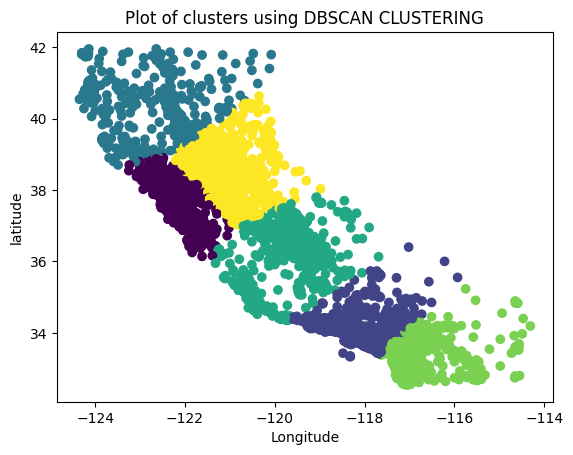

In [17]:
plt.figure()
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=clusters_km)
plt.xlabel("Longitude")
plt.ylabel("latitude")
plt.title("Plot of clusters using DBSCAN CLUSTERING")
plt.show()

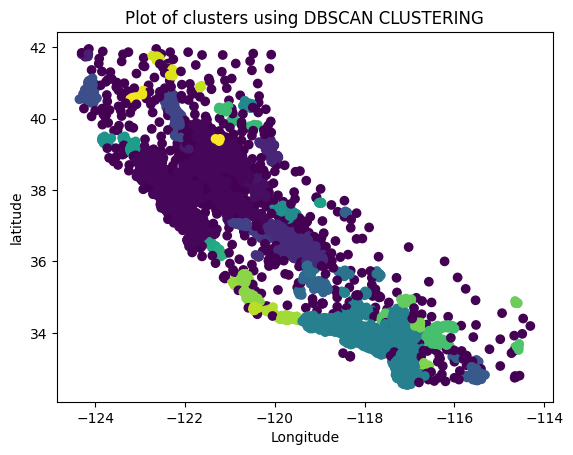

In [21]:
plt.figure()
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=clusters_db)
plt.xlabel("Longitude")
plt.ylabel("latitude")
plt.title("Plot of clusters using DBSCAN CLUSTERING")
plt.show()